# Demonstration: Bidirectional LSTM for Question Classification

##Scenario:
- A research team is building an intelligent system capable of understanding and categorizing natural language questions. When a user submits a query, the system analyzes its structure and semantics using a trained Bidirectional LSTM model. It then accurately predicts the type of information being requested—such as a person, place, or number—enabling downstream components to provide more relevant answers.

### Download and Extract the TREC Dataset

In [3]:
!wget https://cogcomp.seas.upenn.edu/Data/QA/QC/train_5500.label
!wget https://cogcomp.seas.upenn.edu/Data/QA/QC/TREC_10.label

--2025-05-22 07:21:35--  https://cogcomp.seas.upenn.edu/Data/QA/QC/train_5500.label
Resolving cogcomp.seas.upenn.edu (cogcomp.seas.upenn.edu)... 158.130.57.77
Connecting to cogcomp.seas.upenn.edu (cogcomp.seas.upenn.edu)|158.130.57.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 335858 (328K)
Saving to: ‘train_5500.label.2’

train_5500.label.2  100%[===================>] 327.99K  1.09MB/s    in 0.3s    

2025-05-22 07:21:35 (1.09 MB/s) - ‘train_5500.label.2’ saved [335858/335858]

--2025-05-22 07:21:35--  https://cogcomp.seas.upenn.edu/Data/QA/QC/TREC_10.label
Resolving cogcomp.seas.upenn.edu (cogcomp.seas.upenn.edu)... 158.130.57.77
Connecting to cogcomp.seas.upenn.edu (cogcomp.seas.upenn.edu)|158.130.57.77|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23354 (23K)
Saving to: ‘TREC_10.label.2’

TREC_10.label.2     100%[===================>]  22.81K  --.-KB/s    in 0.07s   

2025-05-22 07:21:36 (314 KB/s) - ‘TREC_10.label.2’ saved

### Import Required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

### Load and Preprocess the Dataset

In [5]:
def load_data(file_path):
    questions = []
    labels = []
    with open(file_path, 'r', encoding='latin-1') as file:
        for line in file:
            parts = line.strip().split(' ', 1)
            label = parts[0].split(':')[0]
            question = parts[1]
            questions.append(question)
            labels.append(label)
    return pd.DataFrame({'question': questions, 'label': labels})

### Load training and test datasets

In [6]:
train_df = load_data('train_5500.label')
test_df = load_data('TREC_10.label')

### Combine datasets for tokenization

In [7]:
df = pd.concat([train_df, test_df], ignore_index=True)

### Encode labels

In [8]:
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

### Tokenize and pad sequences

In [9]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['question'])
sequences = tokenizer.texts_to_sequences(df['question'])
max_seq_length = max([len(seq) for seq in sequences])
padded = pad_sequences(sequences, maxlen=max_seq_length, padding='post')

### Prepare data

In [10]:
X = padded
y = tf.keras.utils.to_categorical(df['label_encoded'])

### Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

### Build BiLSTM Model

In [12]:
model = Sequential([
    Embedding(input_dim=5000, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### Train the Model

In [13]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=2)

Epoch 1/10
76/76 - 14s - 189ms/step - accuracy: 0.3633 - loss: 1.5279 - val_accuracy: 0.6007 - val_loss: 1.0879
Epoch 2/10
76/76 - 9s - 118ms/step - accuracy: 0.7346 - loss: 0.7873 - val_accuracy: 0.7929 - val_loss: 0.6381
Epoch 3/10
76/76 - 9s - 123ms/step - accuracy: 0.8867 - loss: 0.3908 - val_accuracy: 0.8078 - val_loss: 0.5845
Epoch 4/10
76/76 - 8s - 102ms/step - accuracy: 0.9315 - loss: 0.2224 - val_accuracy: 0.8209 - val_loss: 0.7382
Epoch 5/10
76/76 - 10s - 135ms/step - accuracy: 0.9614 - loss: 0.1375 - val_accuracy: 0.8209 - val_loss: 0.7520
Epoch 6/10
76/76 - 9s - 113ms/step - accuracy: 0.9701 - loss: 0.1024 - val_accuracy: 0.8228 - val_loss: 0.8102
Epoch 7/10
76/76 - 8s - 100ms/step - accuracy: 0.9772 - loss: 0.0897 - val_accuracy: 0.8284 - val_loss: 0.8172
Epoch 8/10
76/76 - 10s - 135ms/step - accuracy: 0.9857 - loss: 0.0592 - val_accuracy: 0.8209 - val_loss: 0.8607
Epoch 9/10
76/76 - 9s - 120ms/step - accuracy: 0.9859 - loss: 0.0471 - val_accuracy: 0.8358 - val_loss: 0.940

### Display model summary after training

In [14]:
print("\nModel Summary After Training:\n")
model.build(input_shape=(None, max_seq_length))
model.summary()


Model Summary After Training:



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 33, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,242,388 (8.55 MB)

 Trainable params: 747,462 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,494,926 (5.70 MB)

### Evaluate the Model

In [15]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_true_labels, y_pred_labels, target_names=label_encoder.classes_))

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

Classification Report:

              precision    recall  f1-score   support

        ABBR       0.67      0.40      0.50        10
        DESC       0.80      0.87      0.84       126
        ENTY       0.77      0.69      0.73       138
         HUM       0.82      0.83      0.82       110
         LOC       0.88      0.95      0.91       103
         NUM       0.95      0.93      0.94       109

    accuracy                           0.84       596
   macro avg       0.81      0.78      0.79       596
weighted avg       0.84      0.84      0.83       596



### Confusion Matrix

<Figure size 1000x700 with 0 Axes>

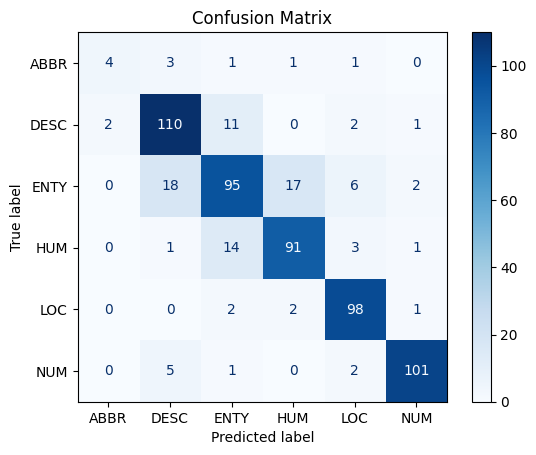

In [16]:
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 7))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### Plot Training History

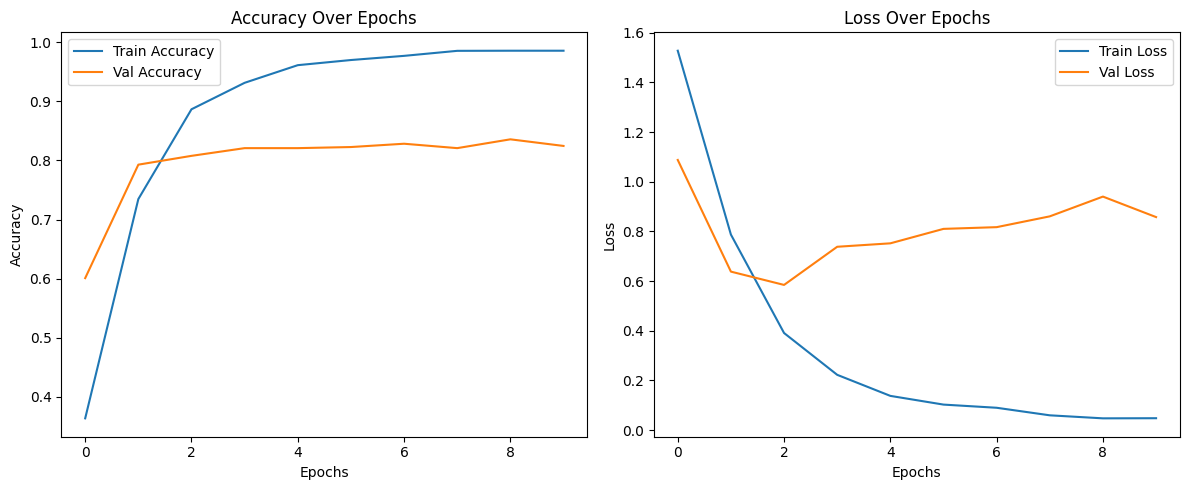

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

### Save the Model and Tokenizer

In [18]:
model.save("bilstm_trec_model.h5")
joblib.dump(tokenizer, "tokenizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

### Real-time Inference Function

In [19]:
def classify_question(question):
    model = tf.keras.models.load_model("bilstm_trec_model.h5")
    tokenizer = joblib.load("tokenizer.pkl")
    label_encoder = joblib.load("label_encoder.pkl")
    seq = tokenizer.texts_to_sequences([question])
    pad = pad_sequences(seq, maxlen=max_seq_length, padding='post')
    pred = model.predict(pad)
    return label_encoder.inverse_transform([np.argmax(pred)])[0]

### Real-time Inference Demo

In [20]:
sample_question = "Who is the CEO of Apple?"
predicted_label = classify_question(sample_question)
print(f"\nPredicted Category for Sample Question: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step

Predicted Category for Sample Question: HUM
